# NB 12c — LSTM-Forecaster (drift-mitigated input)

**Goal.** A *forecasting* sequence model on a small, drift-stable channel set, scored by forecast residual.
Different failure mode than the LSTM-AE in NB 12 / 12b: the model predicts the **next H rows** from the
previous **L rows**, and anomaly score = MSE between predicted and actual H-row block.

**Why it has a chance where NB 12 / 12b failed.**
- NB 12 saw all 58 channels, including the 10 lock-step drifters → reconstruction error rose monotonically across the
  Kaggle test (drift-flood, §4 of `docs/results.md`). Kaggle 0.078–0.112.
- This notebook restricts inputs to a small, drift-stable channel set (`MODE='freq6'` → ch 41–46, the same recipe that
  lifted PCA from 0.522 → 0.887 in NB 11c). The forecaster only has to model a clean spectral signal.
- A forecaster scores *surprise relative to the local trend* — slow, predictable drift is absorbed by the model
  itself, so the score doesn't drift even if the input does. Anomalies are spikes in the forecast residual.

**Mode toggle.** `MODE='freq6'` (default) trains on the freq cluster — apples-to-apples replacement candidate for the
PCA-freq stream of the hybrid champion. `MODE='env3'` trains on `channel_14, 21, 29` — candidate for a third OR
stream complementing the env-zscore stream.

**Companion to:** `11d_pca_hybrid_envzscore.ipynb` (current Kaggle champion, public 0.867 / private 0.915).
**Submission:** commented at the bottom (review thresholds and flag rate before uploading).


## 0 — Setup


In [1]:
import sys, time, os
from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
for p in (PROJECT_ROOT / 'src', PROJECT_ROOT):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import warnings; warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

from sentinel.params import (
    PROCESSED_DIR, MODELS_DIR,
    RANDOM_STATE, WINDOW_SIZE,
    ANOMALY_COLOR, NOMINAL_COLOR,
)
from sentinel.ml_logic.scorer     import broadcast_window_scores_to_rows
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import event_f05, corrected_event_f05
from sentinel.ml_logic.data       import find_anomaly_segments
from kaggle.submission            import make_submission, default_submission_path, submission_summary

tf.keras.utils.set_random_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

KAGGLE_DIR   = PROCESSED_DIR / 'kaggle'
KAGGLE_LEN   = 521_280

print(f'TF {tf.__version__}   GPUs: {tf.config.list_physical_devices("GPU")}')
print(f'KAGGLE_DIR : {KAGGLE_DIR}')
print(f'WINDOW_SIZE: {WINDOW_SIZE}')


TF 2.16.2   GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
KAGGLE_DIR : /Users/helena.schulz.ext/code/alexfederolf/sentinel/data/processed/kaggle
WINDOW_SIZE: 100


## 1 — Mode + load Kaggle arrays

`MODE` chooses which subset of the 58 target channels the forecaster sees.
`freq6` is the safest first experiment (drift-stable, replacement candidate for PCA-freq).


In [2]:
# ── Mode toggle ─────────────────────────────────────────────────────────
MODE = 'freq6'      # 'freq6' (channels 41-46) | 'env3' (channels 14, 21, 29)

CHANNEL_SETS = {
    'freq6': [f'channel_{i}' for i in range(41, 47)],       # PCA-freq replacement
    'env3' : ['channel_14', 'channel_21', 'channel_29'],    # 3rd OR stream candidate
}
TARGET_CHANNELS = CHANNEL_SETS[MODE]

# Map channel names → column indices in the 58-column scaled arrays
target_lookup = pd.read_csv(PROJECT_ROOT / 'data/raw/target_channels.csv')['target_channels'].tolist()
CH_IDX        = np.array([target_lookup.index(n) for n in TARGET_CHANNELS], dtype=int)
N_FEAT        = len(CH_IDX)

# ── Load Kaggle-split arrays ────────────────────────────────────────────
y_train_full = np.load(KAGGLE_DIR / 'y_train_full.npy')
y_train_row  = np.load(KAGGLE_DIR / 'y_train_row.npy')
train_scaled = np.load(KAGGLE_DIR / 'train_full_scaled.npy', mmap_mode='r')
test_scaled  = np.load(KAGGLE_DIR / 'test_scaled.npy')
test_ids     = np.load(KAGGLE_DIR / 'test_ids.npy')

print(f'MODE          : {MODE!r}')
print(f'TARGET_CHANNELS ({N_FEAT}): {TARGET_CHANNELS}')
print(f'CH_IDX        : {CH_IDX.tolist()}')
print(f'train_scaled  : {train_scaled.shape}  (row-level, mmap)')
print(f'test_scaled   : {test_scaled.shape}')
print(f'test_ids      : {test_ids.shape}  range [{test_ids.min()}, {test_ids.max()}]')


MODE          : 'freq6'
TARGET_CHANNELS (6): ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']
CH_IDX        : [29, 30, 31, 32, 33, 34]
train_scaled  : (14728321, 58)  (row-level, mmap)
test_scaled   : (521280, 58)
test_ids      : (521280,)  range [14728321, 15249600]


## 1b — Boundary check: keep splits out of anomaly events

Same routine as NB 12b: snap `TRAIN_END` / `VAL_END` to the nearest row index whose ±2,000-row
neighbourhood is fully nominal. Keeps train/val/test_internal disjoint from any event boundary.


In [3]:
from scipy.ndimage import uniform_filter1d

TRAIN_END_TARGET = 10_700_000
VAL_END_TARGET   = 12_700_000
MIN_CLEAR        = 2_000
SEARCH_RADIUS    = 100_000

def find_clean_boundary(y_row, target, min_clear=MIN_CLEAR, radius=SEARCH_RADIUS):
    n = len(y_row)
    lo = max(0, target - radius)
    hi = min(n, target + radius)
    window = y_row[lo:hi].astype(np.int32)
    k = 2 * min_clear + 1
    local_sum = uniform_filter1d(window, size=k, mode='nearest') * k
    clean = (local_sum == 0)
    if not clean.any():
        raise ValueError(f'No clean ±{min_clear:,}-row gap within ±{radius:,} of {target:,}')
    clean_abs = np.where(clean)[0] + lo
    return int(clean_abs[np.abs(clean_abs - target).argmin()])

TRAIN_END = find_clean_boundary(y_train_row, TRAIN_END_TARGET)
VAL_END   = find_clean_boundary(y_train_row, VAL_END_TARGET)
n_full    = len(train_scaled)

print(f'TRAIN_END : {TRAIN_END:>10,}  (shift {TRAIN_END - TRAIN_END_TARGET:+,})')
print(f'VAL_END   : {VAL_END:>10,}  (shift {VAL_END   - VAL_END_TARGET:+,})')
print(f'Block sizes — train={TRAIN_END:,}  val={VAL_END-TRAIN_END:,}  test_internal={n_full-VAL_END:,}')
print(f'Anom in train : {int(y_train_row[:TRAIN_END].sum()):>9,}')
print(f'Anom in val   : {int(y_train_row[TRAIN_END:VAL_END].sum()):>9,}')
print(f'Anom in test  : {int(y_train_row[VAL_END:].sum()):>9,}')


TRAIN_END : 10,700,000  (shift +0)
VAL_END   : 12,700,000  (shift +0)
Block sizes — train=10,700,000  val=2,000,000  test_internal=2,028,321
Anom in train : 1,113,371
Anom in val   :   215,798
Anom in test  :   214,935


## 2 — Build forecast samples (input + target, both fully nominal)

A sample is a pair of consecutive **non-overlapping** row blocks:

```
input  rows[t        : t + LOOKBACK ]    →  (LOOKBACK,  N_FEAT)
target rows[t+LOOKBACK: t + LOOKBACK+H]   →  (H,         N_FEAT)
```

We require the entire `LOOKBACK + H` span to be anomaly-free, otherwise the loss would teach the
forecaster that anomaly→anomaly transitions are normal.

`stride = LOOKBACK` makes samples non-overlapping (consistent with the project's window convention).


In [4]:
LOOKBACK = WINDOW_SIZE     # 100 — matches the project's window convention
HORIZON  = 10              # forecast next 10 rows (~10 % of a window)
SPAN     = LOOKBACK + HORIZON
FIT_SIZE = 30_000          # tail-most clean samples to train on

# 1) Cumulative anomaly count over the train portion → vectorised "is span clean?"
y_train_portion = y_train_row[:TRAIN_END].astype(np.int32)
cumsum          = np.concatenate([[0], y_train_portion.cumsum()])

# 2) Candidate sample starts: stride = LOOKBACK (non-overlapping inputs)
candidate_starts = np.arange(0, TRAIN_END - SPAN + 1, LOOKBACK, dtype=np.int64)
clean_mask       = (cumsum[candidate_starts + SPAN] - cumsum[candidate_starts]) == 0
clean_starts     = candidate_starts[clean_mask]

# 3) Take the tail (closest to TRAIN_END → most representative of the val/test regime)
fit_starts = clean_starts[-FIT_SIZE:]
print(f'Eligible clean spans (train portion)  : {len(clean_starts):>8,}')
print(f'Selected for training                 : {len(fit_starts):>8,}  (tail)')
print(f'Span coverage                         : rows [{fit_starts[0]:,}, {fit_starts[-1]+SPAN:,}]')

# 4) Materialise (X_fit, Y_fit). Memory: 30k × 110 × N_FEAT × 4 B ≈ 80 MB for N_FEAT=6.
sub = np.ascontiguousarray(train_scaled[:, CH_IDX]).astype(np.float32)

idx_in  = (fit_starts[:, None] + np.arange(LOOKBACK))                 # (n, LOOKBACK)
idx_out = (fit_starts[:, None] + LOOKBACK + np.arange(HORIZON))       # (n, HORIZON)
X_fit   = sub[idx_in]                                                  # (n, LOOKBACK, N_FEAT)
Y_fit   = sub[idx_out]                                                 # (n, HORIZON,  N_FEAT)

print(f'X_fit shape  : {X_fit.shape}  dtype={X_fit.dtype}')
print(f'Y_fit shape  : {Y_fit.shape}  dtype={Y_fit.dtype}')
print(f'X_fit stats  : mean={X_fit.mean():+.4f}  std={X_fit.std():.4f}  '
      f'(scaled inputs — already standardised by the prep pipeline)')


Eligible clean spans (train portion)  :   95,706
Selected for training                 :   30,000  (tail)
Span coverage                         : rows [7,308,900, 10,699,910]
X_fit shape  : (30000, 100, 6)  dtype=float32
Y_fit shape  : (30000, 10, 6)  dtype=float32
X_fit stats  : mean=-0.1077  std=0.5963  (scaled inputs — already standardised by the prep pipeline)


## 3 — LSTM-Forecaster architecture

Compact, **causal** (no bidirectional layers — the forecaster cannot see the future):

```
Input  (LOOKBACK, N_FEAT)
  → LSTM(64,  return_sequences=True,  dropout=0.1)
  → LSTM(32,  return_sequences=False, dropout=0.1)
  → Dense(HORIZON × N_FEAT)
  → Reshape((HORIZON, N_FEAT))
Output (HORIZON, N_FEAT)
```

≈ 25 k parameters for `freq6` (N_FEAT=6). Cheap to train (~1–2 s/epoch CPU on 30k samples).


In [5]:
HIDDEN_1 = 64
HIDDEN_2 = 32
DROPOUT  = 0.1

def build_lstm_forecaster(lookback, horizon, n_feat,
                          hidden_1=HIDDEN_1, hidden_2=HIDDEN_2, dropout=DROPOUT):
    inputs = layers.Input(shape=(lookback, n_feat))
    x = layers.LSTM(hidden_1, return_sequences=True,  dropout=dropout)(inputs)
    x = layers.LSTM(hidden_2, return_sequences=False, dropout=dropout)(x)
    x = layers.Dense(horizon * n_feat)(x)
    outputs = layers.Reshape((horizon, n_feat))(x)
    model = Model(inputs, outputs, name=f'lstm_forecaster_{n_feat}ch_h{horizon}')
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_lstm_forecaster(LOOKBACK, HORIZON, N_FEAT)
model.summary()


Model: "lstm_forecaster_6ch_h10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 64)        │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 60)             │         1,980 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 10, 6)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,572 (127.23 KB)

 Trainable params: 32,572 (127.23 KB)

 Non-trainable params: 0 (0.00 B)

## 4 — Train

EarlyStopping (patience=3, min_delta=5e-4) and ReduceLROnPlateau, identical to NB 12b's regime.


Epoch 1/30
211/211 - 9s - 41ms/step - loss: 0.0970 - val_loss: 0.0539 - learning_rate: 0.0010
Epoch 2/30
211/211 - 6s - 29ms/step - loss: 0.0483 - val_loss: 0.0479 - learning_rate: 0.0010
Epoch 3/30
211/211 - 6s - 29ms/step - loss: 0.0463 - val_loss: 0.0466 - learning_rate: 0.0010
Epoch 4/30
211/211 - 6s - 29ms/step - loss: 0.0455 - val_loss: 0.0459 - learning_rate: 0.0010
Epoch 5/30
211/211 - 6s - 30ms/step - loss: 0.0447 - val_loss: 0.0459 - learning_rate: 0.0010
Epoch 6/30
211/211 - 6s - 30ms/step - loss: 0.0439 - val_loss: 0.0457 - learning_rate: 0.0010
Epoch 7/30
211/211 - 6s - 30ms/step - loss: 0.0434 - val_loss: 0.0463 - learning_rate: 0.0010
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.

Trained in 0.8 min  (7 epochs)


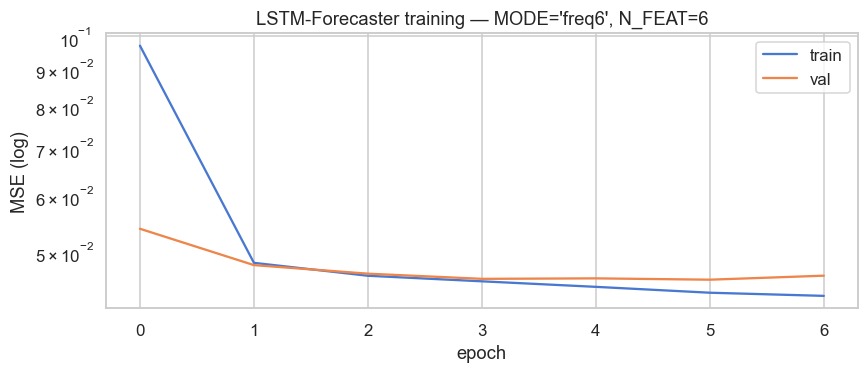

In [6]:
EPOCHS     = 30
BATCH_SIZE = 128

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, min_delta=5e-4,
        restore_best_weights=True, verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2,
        min_lr=1e-5, verbose=1,
    ),
]

t0 = time.time()
history = model.fit(
    X_fit, Y_fit,
    validation_split=0.1,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=2, shuffle=True,
)
train_seconds = time.time() - t0
n_ep = len(history.history['loss'])
print(f'\nTrained in {train_seconds/60:.1f} min  ({n_ep} epochs)')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(history.history['loss'],     label='train', lw=1.5)
ax.plot(history.history['val_loss'], label='val',   lw=1.5)
ax.set_yscale('log')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE (log)')
ax.set_title(f'LSTM-Forecaster training — MODE={MODE!r}, N_FEAT={N_FEAT}')
ax.legend(); plt.tight_layout(); plt.show(); plt.close()


## 5 — Forecast-residual scoring helper

Reduces an arbitrary row array to **one anomaly score per 100-row window** (consistent with §3.1 of
`docs/results.md` — window-MSE > per-row MSE). Then broadcast to row level for thresholding.

For window `i ≥ 1`:
- Input  = the previous window's rows.
- Target = the **first H rows** of window `i`.
- Score  = mean squared error between the forecast and the target H-row block (over H × N_FEAT).

Window 0 has no preceding window in the array → it inherits window 1's score (a 100-row boundary
artifact in 521 k+ rows is negligible).


In [7]:
def forecaster_score_rows(model, X_rows, lookback=LOOKBACK, horizon=HORIZON,
                          ch_idx=CH_IDX, batch=256):
    """Return a row-level forecast-residual score for every row in X_rows.

    X_rows : (n_rows, n_total_channels) — full 58-channel array.
    Returns : (n_rows,) float32, threshold-ready.
    """
    arr = np.ascontiguousarray(X_rows[:, ch_idx]).astype(np.float32)
    n   = arr.shape[0]
    n_win = n // lookback                  # number of complete 100-row windows
    if n_win < 2:
        return np.zeros(n, dtype=np.float32)

    # Build inputs / targets for windows 1 .. n_win-1
    win_starts = np.arange(1, n_win) * lookback                              # (n_win-1,)
    in_idx     = win_starts[:, None] - lookback + np.arange(lookback)         # (n_win-1, lookback)
    out_idx    = win_starts[:, None] + np.arange(horizon)                     # (n_win-1, horizon)
    X_in       = arr[in_idx]                                                  # (n_win-1, lookback, N_FEAT)
    Y_true     = arr[out_idx]                                                 # (n_win-1, horizon,  N_FEAT)

    Y_pred = model.predict(X_in, batch_size=batch, verbose=0)                # (n_win-1, horizon, N_FEAT)
    win_err = ((Y_pred - Y_true) ** 2).mean(axis=(1, 2)).astype(np.float32)  # (n_win-1,)

    # Window 0 inherits window 1's score (no preceding context in this slice)
    win_scores = np.concatenate([[win_err[0]], win_err]).astype(np.float32)  # (n_win,)
    return broadcast_window_scores_to_rows(win_scores, n_rows=n, win=lookback)

print('forecaster_score_rows defined.')


forecaster_score_rows defined.


## 6 — Score val + test_internal


In [8]:
X_val           = np.ascontiguousarray(train_scaled[TRAIN_END:VAL_END]).astype(np.float32)
y_val           = y_train_row[TRAIN_END:VAL_END].astype(np.int8)
X_test_internal = np.ascontiguousarray(train_scaled[VAL_END:]).astype(np.float32)
y_test_internal = y_train_row[VAL_END:].astype(np.int8)

t0 = time.time()
val_scores  = forecaster_score_rows(model, X_val)
test_scores = forecaster_score_rows(model, X_test_internal)
print(f'score (val + test_internal) : {time.time()-t0:.1f}s')

print(f'  val  range : [{val_scores.min():.5f}, {val_scores.max():.5f}]')
print(f'  test range : [{test_scores.min():.5f}, {test_scores.max():.5f}]')
print(f'  val  nominal mean = {val_scores[y_val==0].mean():.5f}')
print(f'  val  anomaly mean = {val_scores[y_val==1].mean():.5f}')
print(f'  test nominal mean = {test_scores[y_test_internal==0].mean():.5f}')
print(f'  test anomaly mean = {test_scores[y_test_internal==1].mean():.5f}')


score (val + test_internal) : 2.3s
  val  range : [0.01364, 176.05156]
  test range : [0.01554, 180.01883]
  val  nominal mean = 0.05474
  val  anomaly mean = 0.84360
  test nominal mean = 0.06185
  test anomaly mean = 0.10114


## 7 — Tune threshold on val (corrected_event_f05), evaluate on test_internal


In [9]:
def row_prec_rec(y_true, y_pred):
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    return prec, rec

tune    = tune_threshold(val_scores, y_val, metric_fn=corrected_event_f05)
t_best  = float(tune['threshold'])
val_esa = float(tune['score'])
print(f'Val-tuned threshold (corrected_event_f05) : {t_best:.6f}')
print(f'Val corrected F0.5 @ best                 : {val_esa:.4f}')

y_pred_test = (test_scores > t_best).astype(np.int8)
ev  = event_f05(y_test_internal,           y_pred_test)
esa = corrected_event_f05(y_test_internal, y_pred_test)
rp, rr = row_prec_rec(y_test_internal, y_pred_test)

print('\n--- LSTM-Forecaster (val-ESA-tuned threshold) — test_internal ---')
print(f'  threshold     : {t_best:.6f}')
print(f'  event F0.5    : {ev["f_score"]:.4f}   recall {ev["recall"]:.4f}   precision {ev["precision"]:.4f}')
print(f'  ESA F0.5      : {esa["f_score"]:.4f}   TNR {esa["tnr"]:.4f}')
print(f'  row precision : {rp:.4f}   row recall {rr:.4f}')
print(f'  test flag rate: {y_pred_test.mean():.4%}')

n_evt_total = sum(1 for _ in find_anomaly_segments(y_test_internal))
n_evt_hit   = sum(int(y_pred_test[ev2['start']:ev2['end']+1].any())
                  for ev2 in find_anomaly_segments(y_test_internal))
print(f'  events hit    : {n_evt_hit}/{n_evt_total}')


Val-tuned threshold (corrected_event_f05) : 0.248798
Val corrected F0.5 @ best                 : 0.4348

--- LSTM-Forecaster (val-ESA-tuned threshold) — test_internal ---
  threshold     : 0.248798
  event F0.5    : 0.4054   recall 0.1200   precision 1.0000
  ESA F0.5      : 0.4054   TNR 0.9999
  row precision : 0.8880   row recall 0.0062
  test flag rate: 0.0740%
  events hit    : 3/25


## 8 — Timeline plots


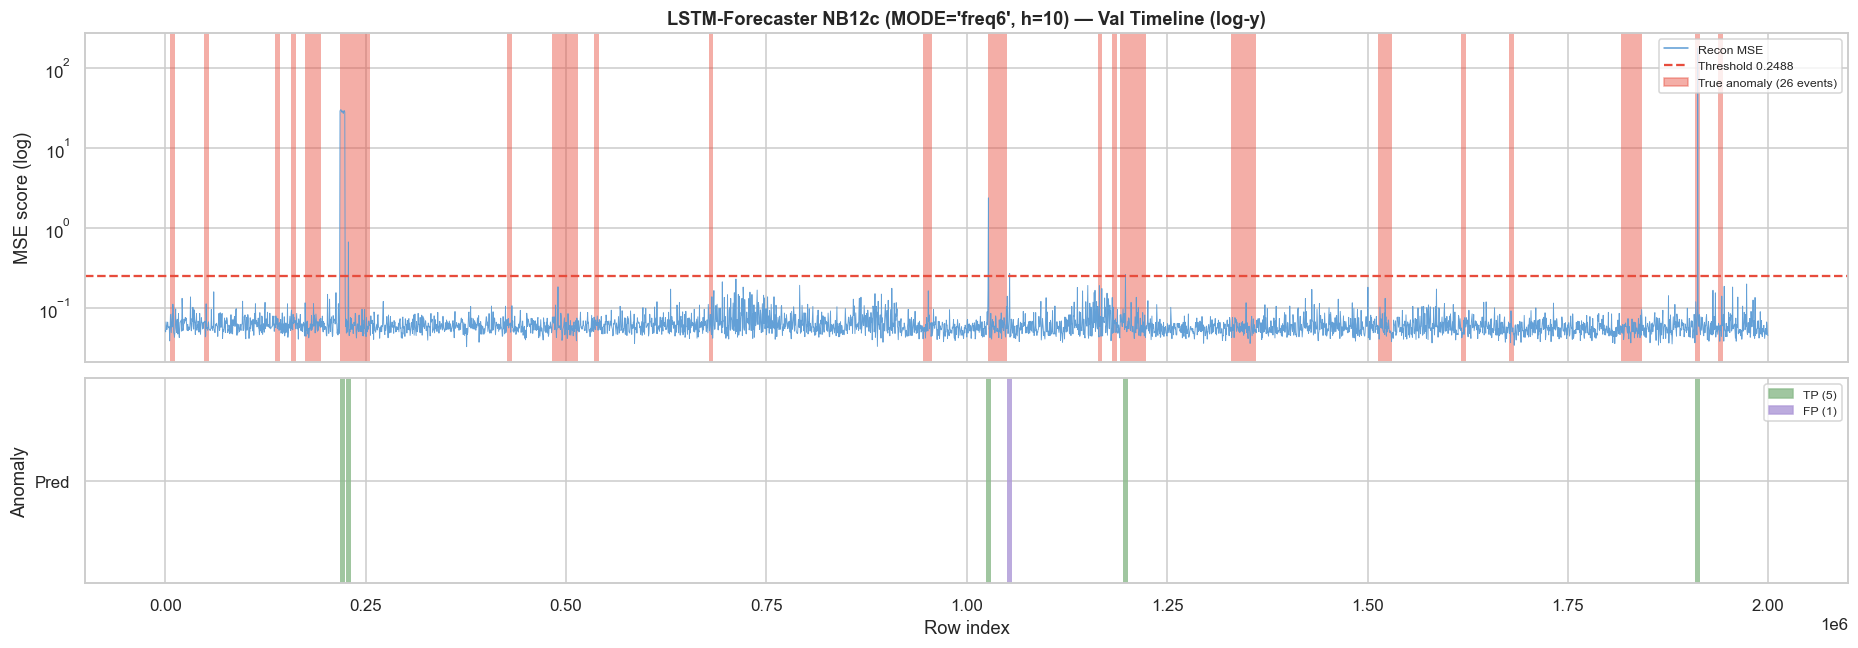

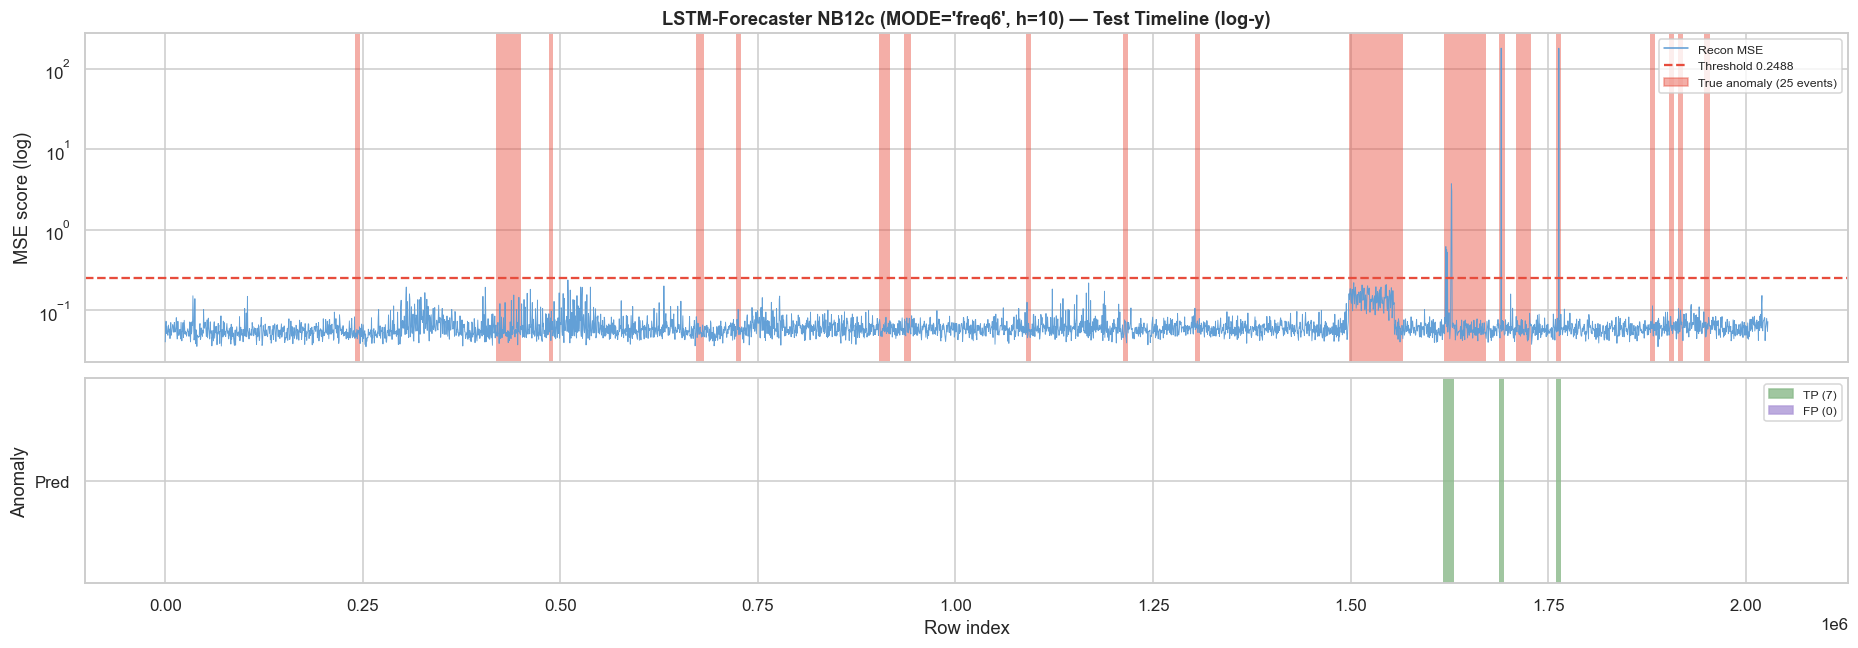

In [10]:
from sentinel.ml_logic.viz import plot_timeline

MODEL_NAME = f'LSTM-Forecaster NB12c (MODE={MODE!r}, h={HORIZON})'

_ = plot_timeline(val_scores, y_val, t_best,
                  f'{MODEL_NAME} — Val Timeline (log-y)', log_y=True)
plt.show(); plt.close()

_ = plot_timeline(test_scores, y_test_internal, t_best,
                  f'{MODEL_NAME} — Test Timeline (log-y)', log_y=True)
plt.show(); plt.close()


## 9 — Kaggle scoring + threshold candidates

Same multi-candidate calibration as NB 12b. Goal: pick a threshold whose Kaggle flag rate stays
in a sane band (≈ 0.5 % – 10 %), avoiding the drift-flood pathology (§4).


In [11]:
X_kaggle      = test_scaled.astype(np.float32, copy=False)
kaggle_scores = forecaster_score_rows(model, X_kaggle)
print(f'kaggle_scores range : [{kaggle_scores.min():.5f}, {kaggle_scores.max():.5f}]')
print(f'test_internal range : [{test_scores.min():.5f}, {test_scores.max():.5f}]')
print(f'val (nominal) range : [{val_scores[y_val==0].min():.5f}, {val_scores[y_val==0].max():.5f}]')
print()

val_nom_scores = val_scores[y_val == 0]

candidates = {
    'A_val_ESA_tuned' : t_best,
    'B_val_nom_p99'   : float(np.percentile(val_nom_scores, 99.0)),
    'C_val_nom_p99_9' : float(np.percentile(val_nom_scores, 99.9)),
    'E_testint_p95'   : float(np.percentile(test_scores,    95.0)),
    'F_testint_p98'   : float(np.percentile(test_scores,    98.0)),
    'G_testint_p99'   : float(np.percentile(test_scores,    99.0)),
    'H_kaggle_p95'    : float(np.percentile(kaggle_scores,  95.0)),
    'I_kaggle_p98'    : float(np.percentile(kaggle_scores,  98.0)),
    'J_kaggle_p99'    : float(np.percentile(kaggle_scores,  99.0)),
}

rows = []
for name, thr in candidates.items():
    y_hat_ti = (test_scores   > thr).astype(np.int8)
    y_hat_k  = (kaggle_scores > thr).astype(np.uint8)
    ev    = event_f05(y_test_internal,           y_hat_ti)
    esa   = corrected_event_f05(y_test_internal, y_hat_ti)
    rp, rr = row_prec_rec(y_test_internal, y_hat_ti)
    rows.append({
        'candidate'    : name,
        'threshold'    : round(thr, 5),
        'event_f05'    : round(ev['f_score'],  4),
        'event_rec'    : round(ev['recall'],   4),
        'esa_f05'      : round(esa['f_score'], 4),
        'tnr'          : round(esa['tnr'],     4),
        'ti_flag_rate' : round(float(y_hat_ti.mean()), 4),
        'kg_flag_rate' : round(float(y_hat_k.mean()),  4),
    })
thr_df = pd.DataFrame(rows)
print('--- Threshold-candidate comparison ---')
print('(ti_* = test_internal, kg_* = Kaggle flag-rate preview)')
print(thr_df.to_string(index=False))

safe = thr_df[thr_df['kg_flag_rate'] <= 0.10].copy()
if len(safe) == 0:
    safe = thr_df
best_idx = safe['esa_f05'].idxmax()
winner   = safe.loc[best_idx]
t_submit = float(winner['threshold'])
variant  = winner['candidate']
print(f"\nSelected for Kaggle submission: {variant}")
print(f"  threshold     = {t_submit:.6f}")
print(f"  test_internal : event_f05={winner['event_f05']}  esa_f05={winner['esa_f05']}")
print(f"  ti_flag_rate  = {winner['ti_flag_rate']}")
print(f"  kg_flag_rate  = {winner['kg_flag_rate']}")


kaggle_scores range : [0.01604, 0.35143]
test_internal range : [0.01554, 180.01883]
val (nominal) range : [0.01364, 176.05156]

--- Threshold-candidate comparison ---
(ti_* = test_internal, kg_* = Kaggle flag-rate preview)
      candidate  threshold  event_f05  event_rec  esa_f05    tnr  ti_flag_rate  kg_flag_rate
A_val_ESA_tuned    0.24880     0.4054       0.12   0.4054 0.9999        0.0007        0.0012
  B_val_nom_p99    0.09809     0.0652       0.28   0.0647 0.9931        0.0277        0.0219
C_val_nom_p99_9    0.16983     0.2247       0.16   0.2246 0.9992        0.0033        0.0035
  E_testint_p95    0.07626     0.0312       0.44   0.0305 0.9753        0.0500        0.0445
  F_testint_p98    0.11480     0.0820       0.20   0.0817 0.9962        0.0200        0.0138
  G_testint_p99    0.13981     0.1412       0.20   0.1410 0.9981        0.0100        0.0067
   H_kaggle_p95    0.07424     0.0290       0.48   0.0282 0.9707        0.0552        0.0499
   I_kaggle_p98    0.10256     0.

## 10 — Save model (commented)


In [12]:
# ── Save model ──────────────────────────────────────────────────────────
# import time
# MODELS_DIR.mkdir(exist_ok=True)
# ts = time.strftime('%Y%m%d_%H%M%S')
# model_path = MODELS_DIR / f'lstm_forecaster_nb12c_{MODE}_{ts}.keras'
# model.save(model_path)
# print(f'Model saved → {model_path}')


## 11 — Kaggle submission (commented)

Uncomment after you've reviewed `variant`, `t_submit`, and `kg_flag_rate` in §9.
The filename embeds `MODE`, the chosen variant, and a timestamp so re-runs don't overwrite each other.


In [13]:
# ── Kaggle submission ───────────────────────────────────────────────────
# print(f'Submitting with MODE={MODE!r}  variant={variant}  threshold={t_submit:.6f}')
# y_kaggle = (kaggle_scores > t_submit).astype(np.uint8)
# print(f'  positive rate : {y_kaggle.mean():.4%}  ({int(y_kaggle.sum()):,} / {len(y_kaggle):,})')
#
# import time as _t
# ts = _t.strftime('%Y%m%d_%H%M%S')
# stem = f'lstm_forecaster_nb12c_{MODE}_{variant}_{ts}'
# out_path = default_submission_path(stem)
# submission = make_submission(
#     predictions     = y_kaggle,
#     test_ids        = test_ids,
#     out_path        = out_path,
#     validate_schema = True,
# )
# print(f'\nSubmission written: {out_path}')
# print(submission_summary(submission))
